# HRTF analysis — LS vs MagLS, causality, ITD/ILD, resampling

Verification plots for the binaural stack: the embedded KEMAR datasets (both
projections), the causality property the audit's finding B6 was about, the
interaural cues reconstructed from the SH-domain FIRs, the HRTF resampler,
and the partitioned convolver against a direct reference.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import ambitap_py as at

plt.rcParams.update({
    "figure.dpi": 96, "figure.figsize": (9, 3.2),
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
})
PAL = at.PALETTE
info = at.builtin_hrtf_info()
print(f"AmbiTap C ABI loaded — channels(order 3) = {at.channel_count(3)}, "
      f"built-in HRTF: order {info['order']}, {info['length']} taps @ {info['sample_rate']:.0f} Hz")


AmbiTap C ABI loaded — channels(order 3) = 16, built-in HRTF: order 5, 128 taps @ 44100 Hz


## 1. Causality — the B6 picture

The audit found the shipped MagLS dataset time-aliased: ~36% of its energy sat
*before* the acoustic onset (pre-echo). After the generator fix (phase-trend
extrapolation) and regeneration, both datasets are compact and causal. The
gate below is the same one `scripts/generate_hrtf.py` enforces before it will
write a header.


LS       pre-onset energy:  0.00 %
MagLS    pre-onset energy:  0.49 %
MagLS R  pre-onset energy:  0.49 %


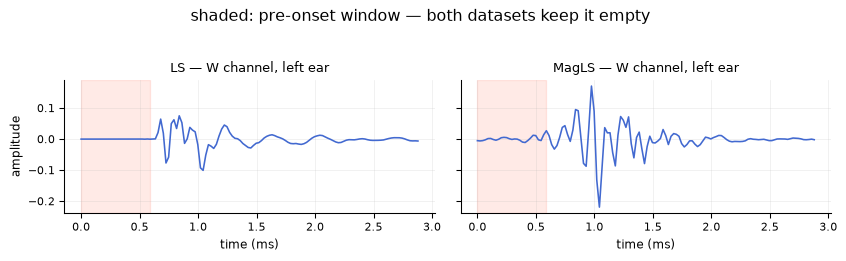

In [2]:
ls_l, ls_r = at.builtin_hrtf(magls=False)
mg_l, mg_r = at.builtin_hrtf(magls=True)
fs = at.builtin_hrtf_info()["sample_rate"]

fig, axes = plt.subplots(1, 2, figsize=(9, 2.6), sharey=True)
tt = np.arange(ls_l.shape[1]) / fs * 1000
for ax, fir, title in [(axes[0], ls_l[0], "LS — W channel, left ear"),
                       (axes[1], mg_l[0], "MagLS — W channel, left ear")]:
    ax.plot(tt, fir, color=PAL[0], lw=1.2)
    ax.axvspan(0, 26 / fs * 1000, color=PAL[2], alpha=0.15)
    ax.set_xlabel("time (ms)"); ax.set_title(title)
axes[0].set_ylabel("amplitude")
fig.suptitle("shaded: pre-onset window — both datasets keep it empty", y=1.03)
fig.tight_layout()

def pre_onset(firs):
    e = firs ** 2
    return e[:, :26].sum() / e.sum()

for name, firs, limit in [("LS", ls_l, 0.005), ("MagLS", mg_l, 0.05), ("MagLS R", mg_r, 0.05)]:
    frac = pre_onset(firs)
    print(f"{name:8s} pre-onset energy: {frac * 100:5.2f} %")
    assert frac < limit


## 2. Magnitude and interaural cues

Per-direction HRTFs are reconstructed from the SH-domain FIRs as
$h_{ear}(t, d) = \sum_c Y_c(d)\, f_{ear,c}(t)$. Below: left/right magnitude
at 90° left (MagLS recovers high-frequency magnitude the order-5 LS
projection smears), then ILD and ITD across the horizon — ITD against the
Woodworth head model as a sanity overlay.


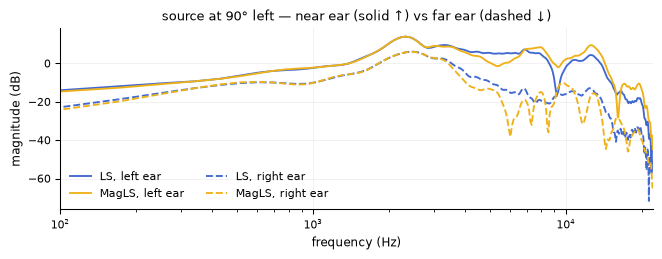

In [3]:
def reconstruct(firs, az, el):
    y = at.evaluate_sh(at.builtin_hrtf_info()["order"], az, el)
    return y @ firs

nfft = 512
freqs = np.fft.rfftfreq(nfft, 1 / fs)
fig, ax = plt.subplots(figsize=(7, 2.8))
for firs, label, color, style in [(ls_l, "LS, left ear", PAL[0], "-"),
                                  (mg_l, "MagLS, left ear", PAL[1], "-"),
                                  (ls_r, "LS, right ear", PAL[0], "--"),
                                  (mg_r, "MagLS, right ear", PAL[1], "--")]:
    h = reconstruct(firs, np.pi / 2, 0.0)
    mag = 20 * np.log10(np.abs(np.fft.rfft(h, nfft)) + 1e-9)
    ax.semilogx(freqs[1:], mag[1:], style, color=color, lw=1.4, label=label)
ax.set_xlim(100, fs / 2); ax.set_xlabel("frequency (Hz)"); ax.set_ylabel("magnitude (dB)")
ax.set_title("source at 90° left — near ear (solid ↑) vs far ear (dashed ↓)")
ax.legend(frameon=False, ncol=2)
fig.tight_layout()


at 90° left: ILD = +10.9 dB, ITD = +658 µs


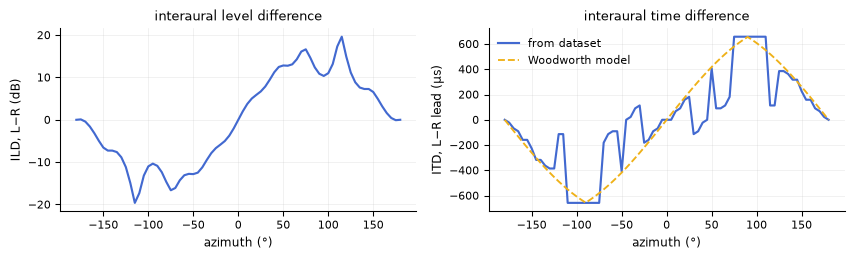

In [4]:
azimuths = np.radians(np.linspace(-180, 180, 73))
ild_db, itd_us = [], []
for a in azimuths:
    hl = reconstruct(mg_l, float(a), 0.0)
    hr = reconstruct(mg_r, float(a), 0.0)
    ild_db.append(10 * np.log10((hl ** 2).sum() / (hr ** 2).sum()))
    xc = np.correlate(hl, hr, mode="full")
    # np.correlate peaks at positive lag when hl is a DELAYED copy of hr;
    # "left ear leads" is therefore a NEGATIVE lag — negate for L-lead-positive.
    itd_us.append(-(xc.argmax() - (len(hl) - 1)) / fs * 1e6)

fig, axes = plt.subplots(1, 2, figsize=(9, 2.8))
axes[0].plot(np.degrees(azimuths), ild_db, color=PAL[0], lw=1.6)
axes[0].set_xlabel("azimuth (°)"); axes[0].set_ylabel("ILD, L−R (dB)")
axes[0].set_title("interaural level difference")
axes[1].plot(np.degrees(azimuths), itd_us, color=PAL[0], lw=1.6, label="from dataset")
r, c = 0.0875, 343.0
wood = [r / c * (np.sin(abs(a)) + abs(a if abs(a) <= np.pi / 2 else np.pi - abs(a)))
        * 1e6 * np.sign(a) for a in azimuths]
axes[1].plot(np.degrees(azimuths), wood, "--", color=PAL[1], lw=1.4, label="Woodworth model")
axes[1].set_xlabel("azimuth (°)"); axes[1].set_ylabel("ITD, L−R lead (µs)")
axes[1].set_title("interaural time difference")
axes[1].legend(frameon=False)
fig.tight_layout()

i90 = np.argmin(np.abs(azimuths - np.pi / 2))
print(f"at 90° left: ILD = {ild_db[i90]:+.1f} dB, ITD = {itd_us[i90]:+.0f} µs")
assert ild_db[i90] > 5              # near ear louder
assert 400 < itd_us[i90] < 900      # human-head ITD range
assert abs(ild_db[len(azimuths) // 2]) < 1   # front: symmetric


## 3. The HRTF resampler

`binaural_renderer::prepare(block, sample_rate)` adapts the 44.1 kHz FIRs to
the host rate with a windowed-sinc resampler. Its frequency response should be
flat in the passband and reject above the original Nyquist when downsampling.


kernel sum 2.0000 (= rate ratio), passband gain 1.0000, peak at 256 (expected 256)


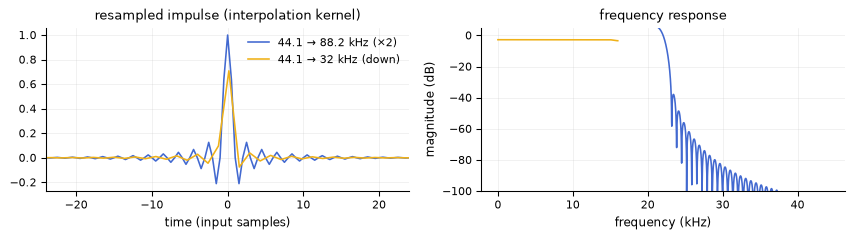

In [5]:
delta = np.zeros(256, np.float32); delta[128] = 1.0
fig, axes = plt.subplots(1, 2, figsize=(9, 2.6))
for rate_out, color, label in [(88200.0, PAL[0], "44.1 → 88.2 kHz (×2)"),
                               (32000.0, PAL[1], "44.1 → 32 kHz (down)")]:
    y = at.resample_fir(delta, 44100.0, rate_out)
    axes[0].plot(np.arange(len(y)) / (rate_out / 44100.0) - 128, y, color=color,
                 lw=1.2, label=label)
    mag = 20 * np.log10(np.abs(np.fft.rfft(y, 4096)) + 1e-12)
    axes[1].plot(np.fft.rfftfreq(4096, 1 / rate_out) / 1000, mag, color=color, lw=1.2)
axes[0].set_xlim(-24, 24); axes[0].set_xlabel("time (input samples)")
axes[0].set_title("resampled impulse (interpolation kernel)")
axes[0].legend(frameon=False)
axes[1].set_xlabel("frequency (kHz)"); axes[1].set_ylabel("magnitude (dB)")
axes[1].set_ylim(-100, 5); axes[1].set_title("frequency response")
fig.tight_layout()

up = at.resample_fir(delta, 44100.0, 88200.0)
# The kernel's sample-sum equals the rate ratio (twice the samples per unit
# time); unity PASSBAND gain means a constant input stays at 1.0 per sample.
flat = at.resample_fir(np.ones(256, np.float32), 44100.0, 88200.0)
assert abs(up.sum() - 2.0) < 0.02
assert np.abs(flat[64:-64] - 1.0).max() < 0.01          # unity passband gain
assert abs(int(np.abs(up).argmax()) - 256) <= 1         # delay scales by the ratio
print(f"kernel sum {up.sum():.4f} (= rate ratio), passband gain "
      f"{flat[64:-64].mean():.4f}, peak at {np.abs(up).argmax()} (expected 256)")


## 4. Partitioned convolver vs direct convolution

The renderer's engine is a partitioned overlap-save FFT convolver. Streaming
noise through it block-by-block must reproduce direct convolution to float
precision — including partial partitions and ring-buffer wraps.


block   16: max |Δ| vs numpy.convolve = 1.43e-06
block   64: max |Δ| vs numpy.convolve = 1.43e-06
block  256: max |Δ| vs numpy.convolve = 1.43e-06


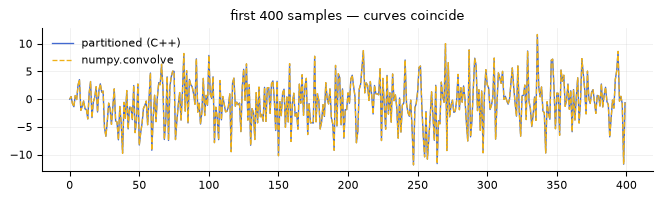

In [6]:
rng = np.random.default_rng(7)
x = rng.standard_normal(4096).astype(np.float32)
ir = (rng.standard_normal(200) * np.exp(-np.arange(200) / 40)).astype(np.float32)
ref = np.convolve(x, ir)[: len(x)]
worst = 0.0
for block in (16, 64, 256):
    err = np.abs(at.convolve(x, ir, block_size=block) - ref).max()
    print(f"block {block:4d}: max |Δ| vs numpy.convolve = {err:.2e}")
    worst = max(worst, err)

fig, ax = plt.subplots(figsize=(7, 2.2))
ax.plot(at.convolve(x, ir)[:400], color=PAL[0], lw=1.0, label="partitioned (C++)")
ax.plot(ref[:400], "--", color=PAL[1], lw=1.0, label="numpy.convolve")
ax.set_title("first 400 samples — curves coincide"); ax.legend(frameon=False)
fig.tight_layout()
assert worst < 1e-4
